# Explain Model Predictions with SHAP, Part B — California Housing

A linear regression model predicts median home prices from census block features — but **which neighborhoods drive the price up or down** for one specific block?

In [part A](06a_xai_iris.ipynb) we introduced SHAP on a k-NN classifier. Here we apply the same tool to the simplest model you already know: **`LinearRegression`** from [lesson 02](02_regression.ipynb).

In this lesson we learn to:

- Compute SHAP values for a fitted linear regression model.
- Read a **waterfall plot** for one house block's predicted log-price.
- Rank features with a **bar plot** (mean absolute SHAP).
- Explore direction and spread with a **beeswarm plot**.
- Zoom in on one feature with a **dependence scatter plot**.


In [1]:
# https://pandas.pydata.org/docs/
import pandas as pd

# https://numpy.org/doc/stable/
import numpy as np

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://seaborn.pydata.org/
import seaborn as sns

# https://shap.readthedocs.io/en/latest/index.html
import shap

# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")

## 1. The California housing dataset

We use the [California housing](https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html) dataset bundled with SHAP — 20,640 census blocks from 1990, subsampled here to 1,000 rows for faster plots.

The target is the **natural log of median house value** in each block. The eight features are:

- **MedInc** — median income in the block group.
- **HouseAge** — median house age in the block group.
- **AveRooms** — average number of rooms per household.
- **AveBedrms** — average number of bedrooms per household.
- **Population** — block group population.
- **AveOccup** — average number of household members.
- **Latitude** — block group latitude.
- **Longitude** — block group longitude.


In [2]:
# Classic housing-price data shipped with the shap package
X, y = shap.datasets.california(n_points=1000)

print(f"Samples: {X.shape[0]:,}   Features: {X.shape[1]}")
X.head()

Samples: 1,000   Features: 8


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14740,4.1518,22.0,5.663073,1.075472,1551.0,4.180593,32.58,-117.05
10101,5.7796,32.0,6.107226,0.927739,1296.0,3.020979,33.92,-117.97
20566,4.3487,29.0,5.930712,1.026217,1554.0,2.910112,38.65,-121.84
2670,2.4511,37.0,4.992958,1.316901,390.0,2.746479,33.20,-115.60
15709,5.0049,25.0,4.319261,1.039578,649.0,1.712401,37.79,-122.43


## 2. Fit a linear regression model

A plain `LinearRegression` learns one coefficient per feature plus an intercept. SHAP will tell us how much each feature **contributed to individual predictions**, not just its global coefficient.


In [3]:
model = LinearRegression()
model.fit(X, y)

coefficients = pd.Series(model.coef_, index=X.columns, name="coefficient")
coefficients.sort_values(ascending=False)

AveBedrms     0.663848
MedInc        0.425630
HouseAge      0.010335
Population    0.000032
AveRooms     -0.116096
AveOccup     -0.260959
Longitude    -0.462716
Latitude     -0.467338
Name: coefficient, dtype: float64

**Coefficients vs SHAP:**

- A **coefficient** is a global slope: "if MedInc rises by 1 unit, log-price rises by $\beta$ on average."
- A **SHAP value** is local: "for *this* block, MedInc pushed the prediction up by *this much*, given the values of all other features."
- For linear models the two stories align, but SHAP still helps when features interact with the background distribution or when you later swap in a non-linear model.


## 3. Compute SHAP values

We pass `model.predict` to `shap.Explainer` along with a 100-row background sample. SHAP compares each house block against that background to allocate credit across features.


In [4]:
# Background distribution: a random subset of training rows
background = shap.utils.sample(
    X,
    100,  # summarize the dataset without using all 1,000 rows
)

explainer = shap.Explainer(
    model.predict,  # explain the continuous log-price prediction
    background,
)

shap_values = explainer(X)
print(f"SHAP shape: {shap_values.shape}  (samples, features)")

ExactExplainer explainer:  66%|██████▌   | 656/1000 [00:00<?, ?it/s]

ExactExplainer explainer:  67%|██████▋   | 671/1000 [00:10<00:02, 143.64it/s]

ExactExplainer explainer:  69%|██████▊   | 686/1000 [00:10<00:02, 144.27it/s]

ExactExplainer explainer:  70%|███████   | 705/1000 [00:10<00:01, 163.17it/s]

ExactExplainer explainer:  73%|███████▎  | 730/1000 [00:10<00:01, 195.55it/s]

...

ExactExplainer explainer:  93%|█████████▎| 932/1000 [00:11<00:00, 219.61it/s]

ExactExplainer explainer:  96%|█████████▌| 955/1000 [00:11<00:00, 211.15it/s]

ExactExplainer explainer:  98%|█████████▊| 977/1000 [00:11<00:00, 209.99it/s]

ExactExplainer explainer: 1001it [00:11, 29.48it/s]                          

SHAP shape: (1000, 8)  (samples, features)


## 4. One prediction — waterfall plot

Pick one block and read the waterfall from bottom to top:

1. **Base value** $E[f(X)]$ — the average predicted log-price across the background.
2. **Colored bars** — each feature's SHAP contribution (red = pushes price up, blue = pushes down).
3. **$f(x)$** at the top — the model's predicted log-price for this specific block.

Because SHAP values are additive: `base + sum(SHAP) = prediction`.


Block index: 20
Predicted log(median price): 1.681


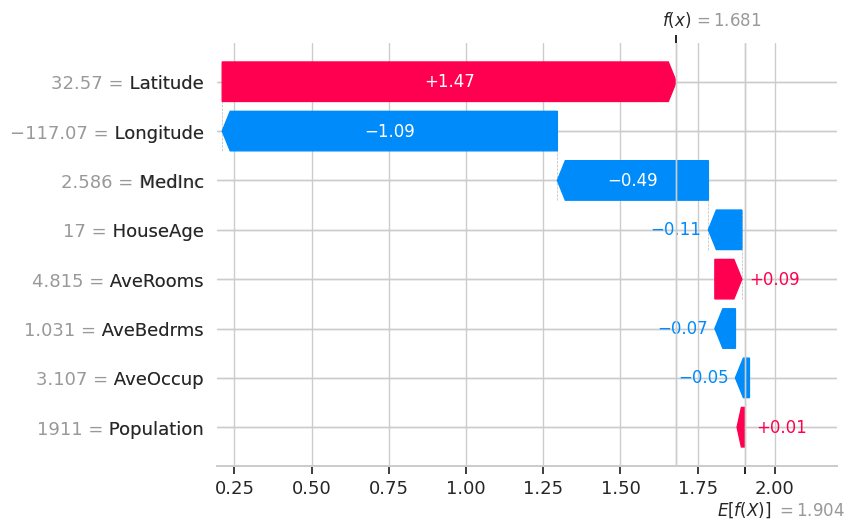

In [5]:
sample_idx = 20
predicted_log_price = model.predict(X.iloc[[sample_idx]])[0]

print(f"Block index: {sample_idx}")
print(f"Predicted log(median price): {predicted_log_price:.3f}")

shap.plots.waterfall(shap_values[sample_idx])

**How to interpret this block:**

- Large **red** bars are features that made this neighborhood **more expensive** than average (often MedInc or coastal latitude/longitude).
- Large **blue** bars pulled the prediction **below** average (for example high AveOccup or inland location).
- Small bars mean that feature barely moved the needle for this particular block.


## 5. Global importance — bar plot

Average the **absolute** SHAP values across all blocks to rank features by overall impact:


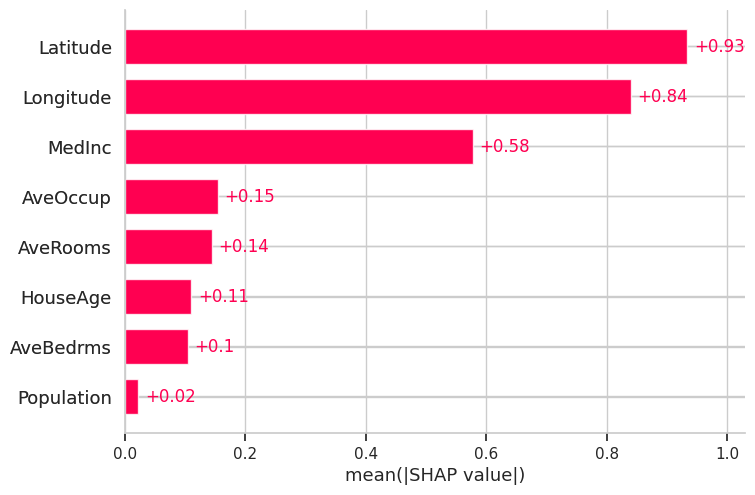

In [6]:
shap.plots.bar(shap_values)

**Reading the bar chart:**

- Top features are the ones that most often **move predictions away from the average**, regardless of direction.
- **MedInc** and **location** (Latitude/Longitude) typically dominate California housing models — income and geography explain much of the price variation.
- Features with short bars matter less on average; they may still matter for individual blocks (see the waterfall above).


## 6. Direction and spread — beeswarm plot

The beeswarm shows every block at once:

- **Horizontal position:** SHAP value for that feature on that block.
- **Color:** the feature's actual value (red = high, blue = low).
- Features are sorted by mean absolute impact.


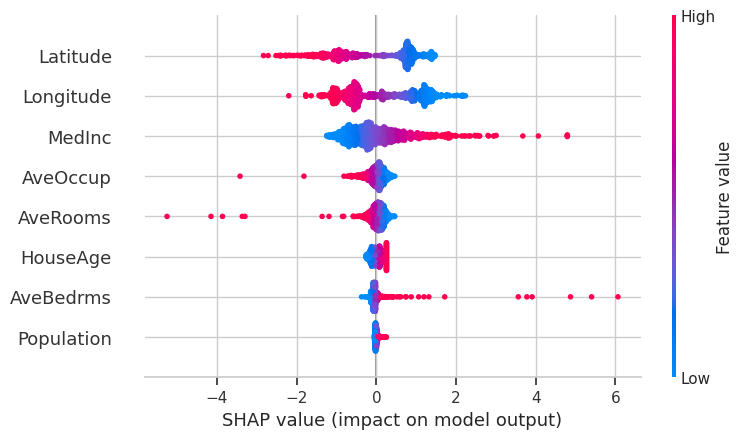

In [7]:
shap.plots.beeswarm(shap_values)

**Patterns to notice:**

- **MedInc:** red dots (high income) on the right $\Rightarrow$ higher income pushes log-price up.
- **Latitude / Longitude:** clusters of red and blue reveal geographic price gradients (coastal vs inland).
- **HouseAge:** if dots stay near zero, age rarely shifts predictions much in this linear model.


## 7. Zoom in on one feature — dependence scatter

A **dependence plot** fixes one feature on the x-axis and plots its SHAP values on the y-axis. Each dot is one block. The histogram along the bottom shows how often each feature value appears.

We compare three features side by side.


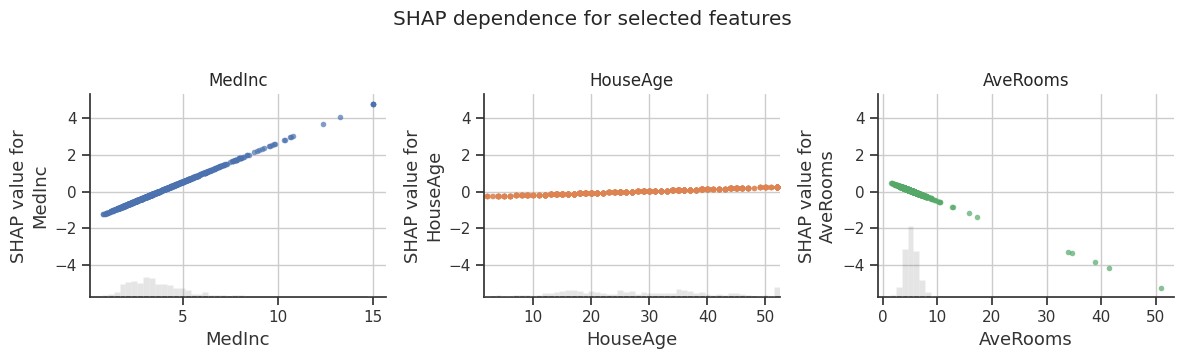

In [8]:
features_to_compare = ["MedInc", "HouseAge", "AveRooms"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(12, 3.5),
    sharey=True,  # same SHAP scale across panels for easy comparison
)

palette = sns.color_palette(n_colors=len(features_to_compare))

for ax, feature, color in zip(axes, features_to_compare, palette):
    shap.plots.scatter(
        shap_values[:, feature],  # SHAP values for this feature across all blocks
        color=color,  # one color per panel
        show=False,  # draw all three panels before calling plt.show()
        alpha=0.7,  # slight transparency to reveal density
        ax=ax,
    )
    ax.set_title(feature)

fig.suptitle("SHAP dependence for selected features", y=1.02)
fig.tight_layout()
plt.show()

**What each panel tells you:**

- **MedInc:** expect a clear upward trend — higher income blocks get higher SHAP contributions.
- **HouseAge:** a flatter cloud means age has a weaker or more mixed effect.
- **AveRooms:** check whether the relationship is linear or bends at extreme room counts.

> **Note:** These dependence plots are closely related to [Partial Dependence Plots](https://christophm.github.io/interpretable-ml-book/pdp.html) and [ICE curves](https://christophm.github.io/interpretable-ml-book/ice.html). SHAP scatter plots show the *local* contribution per instance rather than a marginal average curve.

SHAP ships many more plot types (heatmap, violin, force). See the [SHAP plotting API](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html) to explore them on your own.


## Recap

- SHAP decomposes each prediction into a **base value** plus **per-feature contributions**.
- On linear regression, SHAP complements (and often aligns with) the learned **coefficients**, while staying useful when you move to non-linear models later.
- **Waterfall** $\rightarrow$ one block's story; **bar** $\rightarrow$ global ranking; **beeswarm** $\rightarrow$ direction and spread; **scatter** $\rightarrow$ single-feature behavior.
- For California housing, **income** and **location** usually dominate — exactly the signals you would expect from a housing market.

## References

- [SHAP documentation](https://shap.readthedocs.io/en/latest/index.html)
- [An introduction to explainable AI with Shapley values (original notebook)](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html)
- [SHAP chapter — Interpretable Machine Learning (Molnar)](https://christophm.github.io/interpretable-ml-book/shap.html)
- [Regression lesson](02_regression.ipynb)
- [SHAP part A — Iris classification](06a_xai_iris.ipynb)
